# Linear Support Vector Machine (SVM) on the Iris Dataset

**Objective:** Implement a Linear SVM to classify the Iris dataset (Setosa vs. Non-Setosa), visualize the decision boundary and margin, and discuss how the margin is determined.

**Tasks:**
1. Load and preprocess the Iris dataset.
2. Implement a Linear SVM for binary classification (Setosa vs. Non-Setosa).
3. Visualize the decision boundary and margin.
4. Discuss the concept of the margin and how it influences classification.

## Task 1: Load and Preprocess the Iris Dataset

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
# Load the Iris dataset
iris = datasets.load_iris()

# For easy 2D visualization, we use only 2 features: petal length and petal width
X = iris.data[:, [2, 3]]   # petal length, petal width
y = iris.target            # 0 = Setosa, 1 = Versicolor, 2 = Virginica

feature_names = [iris.feature_names[2], iris.feature_names[3]]

# Convert into a DataFrame for easy viewing
df = pd.DataFrame(X, columns=feature_names)
df['species'] = [iris.target_names[i] for i in y]
df.head()

,petal length (cm),petal width (cm),species
0,1.4,0.2,setosa
1,1.4,0.2,setosa
2,1.3,0.2,setosa
3,1.5,0.2,setosa
4,1.4,0.2,setosa


In [3]:
# Preprocessing: Convert to a BINARY classification problem
# Setosa (class 0)  -> label  1
# Non-Setosa (1, 2) -> label -1
y_binary = np.where(y == 0, 1, -1)

print("Class distribution (Setosa=1, Non-Setosa=-1):")
print(pd.Series(y_binary).value_counts())

Class distribution (Setosa=1, Non-Setosa=-1):
-1    100
 1     50
Name: count, dtype: int64


In [4]:
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary, test_size=0.3, random_state=42, stratify=y_binary
)

# Feature scaling (important for SVM since it is distance/margin based)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training samples:", X_train_scaled.shape[0])
print("Testing samples:", X_test_scaled.shape[0])

Training samples: 105
Testing samples: 45


## Task 2: Implement a Linear SVM for Binary Classification

In [5]:
# Train a Linear SVM classifier
# C is the regularization parameter: a large C tries to classify all training
# points correctly (harder margin); a small C allows a wider (softer) margin.
svm_model = SVC(kernel='linear', C=1.0)
svm_model.fit(X_train_scaled, y_train)

# Predictions
y_pred = svm_model.predict(X_test_scaled)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0

Confusion Matrix:
 [[30  0]
 [ 0 15]]

Classification Report:
               precision    recall  f1-score   support

          -1       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        15

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [6]:
# Inspect the learned model parameters
w = svm_model.coef_[0]      # weight vector (defines orientation of hyperplane)
b = svm_model.intercept_[0] # bias term (defines the offset of hyperplane)

print("Weight vector (w):", w)
print("Bias (b):", b)
print("Number of support vectors:", svm_model.support_vectors_.shape[0])
print("Support vectors:\n", svm_model.support_vectors_)

Weight vector (w): [-1.45245271 -1.01121917]
Bias (b): -1.5995864811298242
Number of support vectors: 4
Support vectors:
 [[-0.24657004 -0.23877628]
 [-0.24657004 -0.23877628]
 [-1.23119538 -0.78086296]
 [-1.05743796 -1.0519063 ]]


## Task 3: Visualize the Decision Boundary and Margin

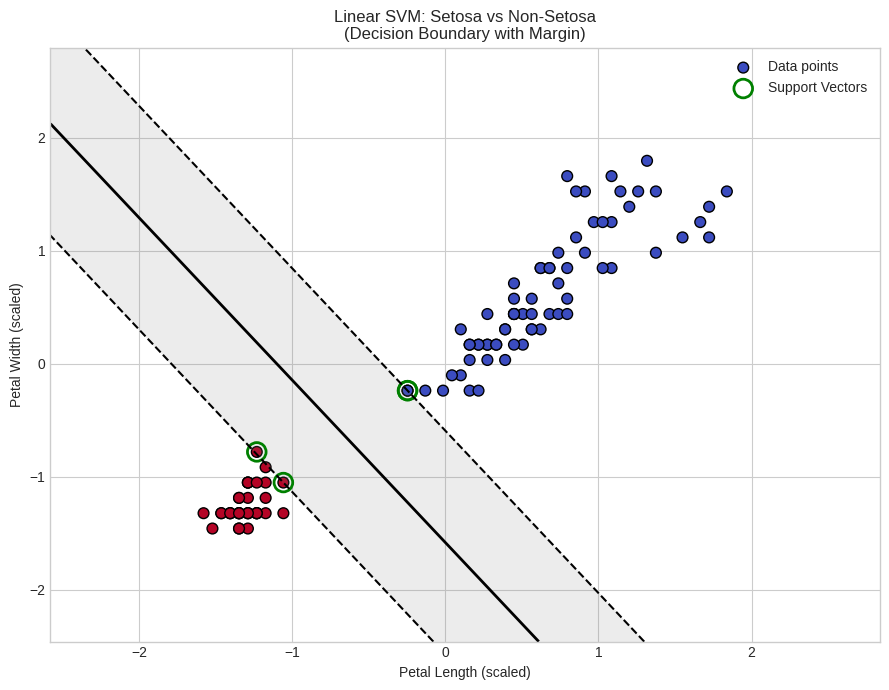

In [7]:
def plot_svm_decision_boundary(model, X, y, ax=None, title="Linear SVM Decision Boundary"):
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 7))

    # Plot the data points
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=60,
                          edgecolors='k', label='Data points')

    # Create a mesh grid to evaluate the decision function over
    ax_xlim = ax.get_xlim() if ax.get_xlim() != (0.0, 1.0) else (X[:,0].min()-1, X[:,0].max()+1)
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                          np.linspace(y_min, y_max, 300))

    # Decision function: distance from the hyperplane
    Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot decision boundary (Z=0) and margins (Z=-1, Z=1)
    ax.contour(xx, yy, Z, colors='k',
               levels=[-1, 0, 1],
               linestyles=['--', '-', '--'],
               linewidths=[1.5, 2, 1.5])

    # Shade the margin region
    ax.contourf(xx, yy, Z, levels=[-1, 1], colors=['gray'], alpha=0.15)

    # Highlight the support vectors
    ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
               s=180, facecolors='none', edgecolors='green', linewidths=2,
               label='Support Vectors')

    ax.set_xlabel('Petal Length (scaled)')
    ax.set_ylabel('Petal Width (scaled)')
    ax.set_title(title)
    ax.legend(loc='best')
    return ax

fig, ax = plt.subplots(figsize=(9, 7))
plot_svm_decision_boundary(svm_model, X_train_scaled, y_train, ax=ax,
                            title="Linear SVM: Setosa vs Non-Setosa\n(Decision Boundary with Margin)")
plt.tight_layout()
plt.show()

In [8]:
# Calculate and display the margin width
# The margin (distance between the two dashed margin lines) = 2 / ||w||
margin_width = 2 / np.linalg.norm(w)
print(f"Norm of weight vector ||w|| = {np.linalg.norm(w):.4f}")
print(f"Margin width (2 / ||w||)   = {margin_width:.4f}")

Norm of weight vector ||w|| = 1.7698
Margin width (2 / ||w||)   = 1.1301


## Bonus: Effect of Different C Values on the Margin

The cell below trains several SVMs with different `C` values to visually demonstrate how the margin width changes.

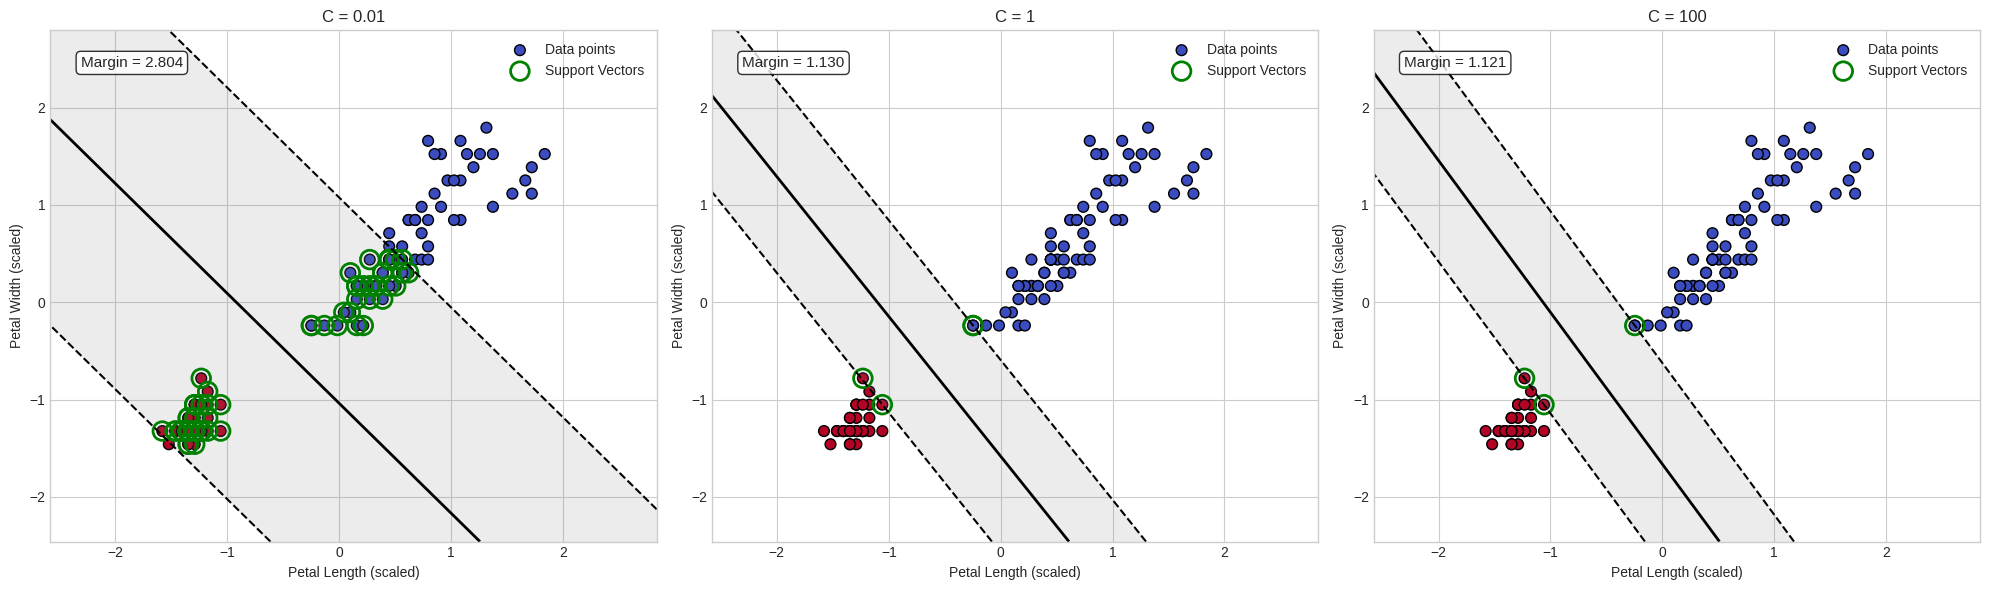

In [9]:
C_values = [0.01, 1, 100]
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, C in zip(axes, C_values):
    model_c = SVC(kernel='linear', C=C)
    model_c.fit(X_train_scaled, y_train)
    plot_svm_decision_boundary(model_c, X_train_scaled, y_train, ax=ax,
                                title=f"C = {C}")
    w_c = model_c.coef_[0]
    margin_c = 2 / np.linalg.norm(w_c)
    ax.text(0.05, 0.95, f"Margin = {margin_c:.3f}", transform=ax.transAxes,
            fontsize=11, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()